
LOADING DATA AND PARAMETERS
Using 578 stars with Mstar ≤ 2.0 M☉
Loaded parameters:
  μ (mean c): -5.623
  σ (std c): 0.541
  Age exponent (a): -0.411
  Mass exponent (b): 1.137

BOOTSTRAP UNCERTAINTY ANALYSIS FOR a AND b PARAMETERS
Running bootstrap analysis...
Bootstrap results from 500 successful fits:
  Age exponent (a): -0.413 ± 0.049
  Mass exponent (b): 1.135 ± 0.106
  Amplitude (c): -5.612 ± 0.319

PARAMETER SIMULATION: ORIGINAL METHOD FOR c, BOOTSTRAP FOR a AND b
Simulated parameters:
  a-values: mean = -0.413, std = 0.047
  b-values: mean = 1.136, std = 0.113
  c-values: mean = -5.610, std = 0.547

SIMULATED MACC RATE DISTRIBUTIONS FROM PARAMETER UNCERTAINTY
Star 179: logAge=7.20, Mstar=1.13 M☉
  Actual Macc: -8.757
  Simulated Macc range: -10.502 to -6.810
Star 424: logAge=6.12, Mstar=0.46 M☉
  Actual Macc: -8.236
  Simulated Macc range: -10.445 to -6.906
Star 320: logAge=6.47, Mstar=1.03 M☉
  Actual Macc: -9.226
  Simulated Macc range: -10.194 to -6.627


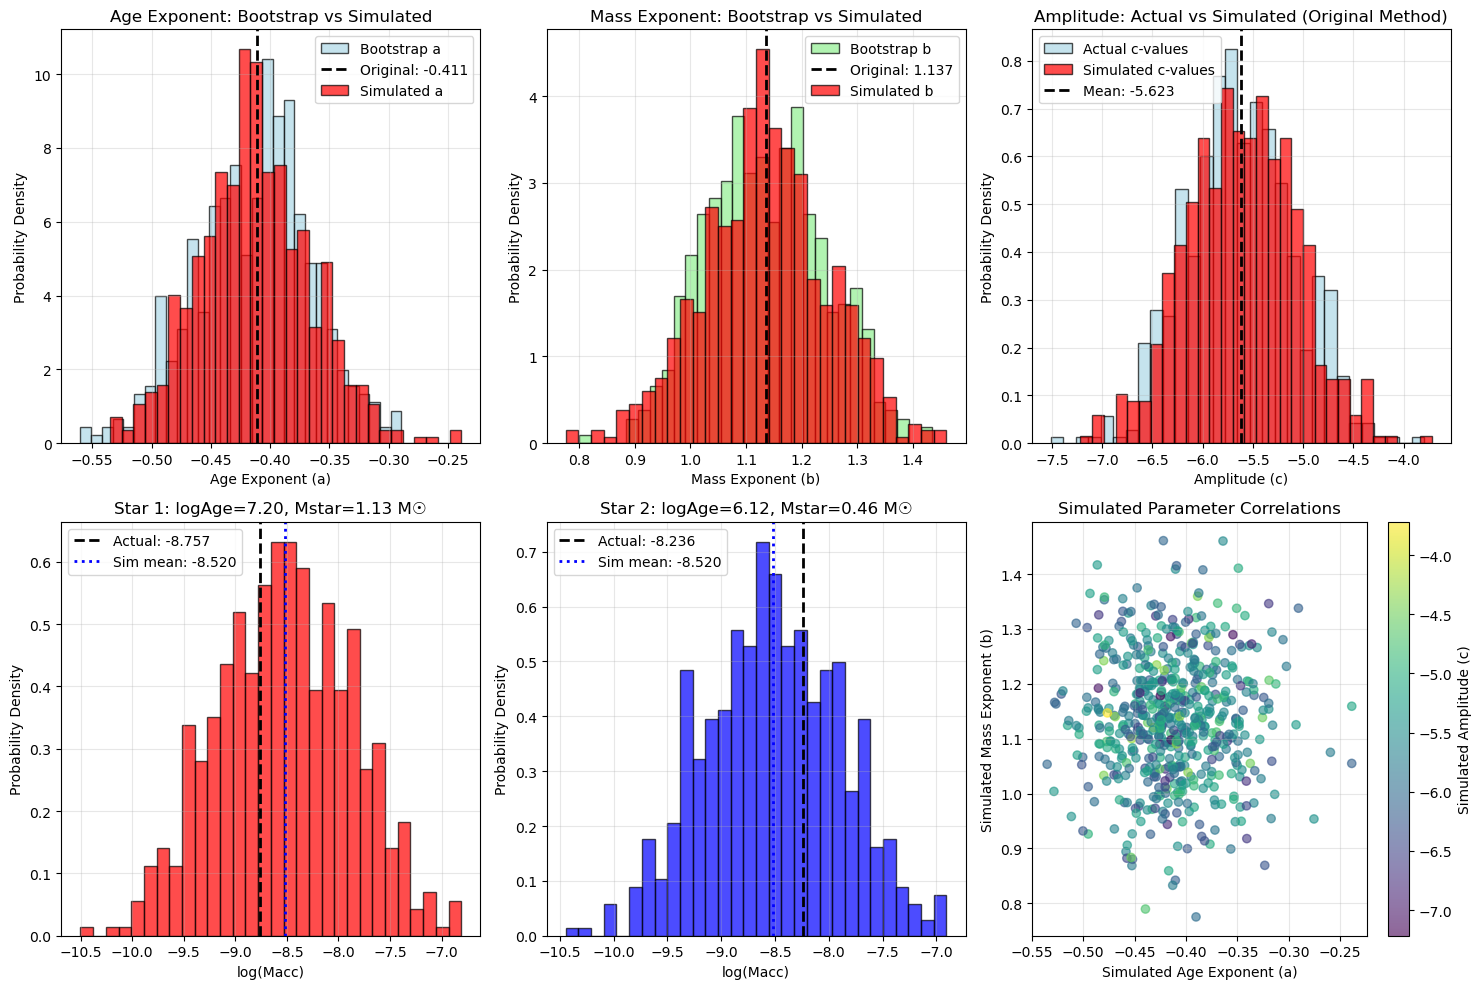


STATISTICAL VALIDATION
Parameter consistency tests (KS p-values):
  Age exponent (a): p = 0.060 ✓ Consistent
  Mass exponent (b): p = 0.408 ✓ Consistent
  Amplitude (c): p = 0.702 ✓ Consistent

COMBINED UNCERTAINTY ANALYSIS REPORT

FINAL MODEL WITH UNCERTAINTIES:
logMacc = a×logAge + b×logMstar + c
where:
  a ~ N(μ=-0.413, σ=0.049)  [Bootstrap uncertainty]
  b ~ N(μ=1.135, σ=0.106)  [Bootstrap uncertainty]
  c ~ N(μ=-5.623, σ=0.541)  [Original residual method]

PRACTICAL IMPLICATIONS:
Star 1: Macc uncertainty = ±0.649 dex (95% range: -9.759 to -7.317)
Star 2: Macc uncertainty = ±0.624 dex (95% range: -9.708 to -7.367)
Star 3: Macc uncertainty = ±0.631 dex (95% range: -9.485 to -7.085)

TOTAL MODEL UNCERTAINTY BREAKDOWN:
• Parameter uncertainty (a,b): ±0.080 dex
• Intrinsic scatter (c): ±0.541 dex
• Combined uncertainty: ±0.555 dex
PDF report skipped
✓ Analysis complete - using original method for c, bootstrap for a and b
✓ Bootstrap results saved to 'bootstrap_results.npy'


In [ ]:
"""
Uncertainty Analysis Code - Bootstrap and Monte Carlo Parameter Estimation
Updated: Jun 29 2026

Input Files:
power_law_model.npy (from main analysis)
stellar_accretion_data.csv (from main analysis)

Output Files:
bootstrap_results.npy
Capstone_Report_Uncertainty_AB.pdf (Section 4) - only if user prompts

1 - bootstrap_results.npy:
    Contains bootstrap-sampled distributions for age exponent (a) and mass exponent (b),
    simulated parameters from the combined method, and summary statistics.
    Stores all uncertainty results for reuse without rerunning the bootstrap analysis.

2 - Capstone_Report_Uncertainty_AB.pdf:
    A comprehensive PDF report containing parameter distribution plots, Macc rate distributions
    for example stars, statistical validation results, and uncertainty interpretation.
    For ease of reading and distribution.

This has 6 sections:
1 - Bootstrap uncertainty analysis for a and b parameters
2 - Parameter simulation using combined method (bootstrap for a,b; residual method for c)
3 - Simulated Macc rate distributions from parameter uncertainty
4 - Visualize parameter and Macc distributions
5 - Statistical validation (KS tests) and uncertainty quantification
6 - PDF report generation with visualizations and summary
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from scipy.special import erfinv
from scipy.stats import ks_2samp
from matplotlib.backends.backend_pdf import PdfPages

# Set random seed for reproducibility
np.random.seed(42)


def gaussian_dist(mu, sigma, n_points):
    """
    Generate random values from a Gaussian distribution using inverse transform sampling.
    
    Parameters:
        mu (float): Mean of the distribution
        sigma (float): Standard deviation of the distribution
        n_points (int): Number of random values to generate
        
    Returns:
        np.ndarray: Array of n_points random values drawn from N(mu, sigma)
    """
    return mu + sigma * np.sqrt(2) * erfinv(2 * np.random.random(n_points) - 1)


def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    """
    Triple power law model for mass accretion rate.
    
    Parameters:
        log_age (float): log10(stellar age in years)
        log_mstar (float): log10(stellar mass in solar masses)
        log_amplitude (float): log10(normalization constant)
        age_exponent (float): Power law exponent for age dependence
        mass_exponent (float): Power law exponent for mass dependence
        
    Returns:
        float: log10(mass accretion rate in solar masses/year)
    """
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar


def load_data():
    """Load pre-computed data and model parameters."""
    df = pd.read_csv('stellar_accretion_data.csv')
    df = df[df['Mstar'] <= 2.0]
    
    model_params = np.load('power_law_model.npy', allow_pickle=True).item()
    
    return df, model_params


def bootstrap_triple_power_law(df, n_bootstraps=500):
    """
    Perform bootstrap resampling to estimate parameter uncertainties.
    
    Parameters:
        df (pd.DataFrame): Input data with logAge, logMstar, logMacc columns
        n_bootstraps (int): Number of bootstrap iterations
        
    Returns:
        tuple: (a_values, b_values, c_values) arrays of bootstrap parameter estimates
    """
    a_values = []
    b_values = []
    c_values = []
    failed_fits = 0
    
    model = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])
    
    for i in range(n_bootstraps):
        # Resample with replacement
        bootstrap_sample = df.sample(n=len(df), replace=True)
        
        log_age_data = bootstrap_sample['logAge'].values
        log_mstar_data = bootstrap_sample['logMstar'].values
        log_macc_data = bootstrap_sample['logMacc'].values
        
        # Set up fit parameters with bounds
        params = model.make_params()
        params.add('log_amplitude', value=-7, min=-12, max=5)
        params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
        params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)
        
        try:
            result = model.fit(log_macc_data, params, 
                             log_age=log_age_data, log_mstar=log_mstar_data)
            a_values.append(result.params['age_exponent'].value)
            b_values.append(result.params['mass_exponent'].value)
            c_values.append(result.params['log_amplitude'].value)
        except Exception:
            failed_fits += 1
            continue
    
    if failed_fits > 0:
        print(f"Warning: {failed_fits} bootstrap fits failed ({failed_fits/n_bootstraps*100:.1f}%)")
    
    return np.array(a_values), np.array(b_values), np.array(c_values)


def compute_actual_c_values(df, age_exp, mass_exp):
    """
    Compute individual c-values from the residual method.
    
    Parameters:
        df (pd.DataFrame): Input data with logAge, logMstar, logMacc columns
        age_exp (float): Fitted age exponent
        mass_exp (float): Fitted mass exponent
        
    Returns:
        np.ndarray: Array of individual c-values
    """
    return df['logMacc'] - (age_exp * df['logAge'] + mass_exp * df['logMstar'])


def simulate_macc_distributions(df, simulated_a, simulated_b, simulated_c, n_examples=3):
    """
    Simulate Macc distributions for example stars.
    
    Parameters:
        df (pd.DataFrame): Input data
        simulated_a (np.ndarray): Simulated age exponent values
        simulated_b (np.ndarray): Simulated mass exponent values
        simulated_c (np.ndarray): Simulated amplitude values
        n_examples (int): Number of example stars to select
        
    Returns:
        list: List of tuples (logAge, logMstar, actual_macc, simulated_macc)
    """
    example_indices = np.random.choice(len(df), size=n_examples, replace=False)
    distributions = []
    
    for idx in example_indices:
        star_age = df.iloc[idx]['logAge']
        star_mass = df.iloc[idx]['logMstar']
        actual_macc = df.iloc[idx]['logMacc']
        
        simulated_macc = (simulated_a * star_age + simulated_b * star_mass + simulated_c)
        distributions.append((star_age, star_mass, actual_macc, simulated_macc))
        
        print(f"Star {idx}: logAge={star_age:.2f}, Mstar={df.iloc[idx]['Mstar']:.2f} M☉")
        print(f"  Actual Macc: {actual_macc:.3f}")
        print(f"  Simulated Macc range: {simulated_macc.min():.3f} to {simulated_macc.max():.3f}")
    
    return distributions


def create_parameter_plots(ax, data, label, color, original_value, title, xlabel):
    """Helper function to create consistent parameter distribution plots."""
    ax.hist(data, bins=30, alpha=0.7, density=True, color=color, 
            label=label, edgecolor='black')
    ax.axvline(original_value, color='black', linestyle='--', linewidth=2, 
               label=f'Original: {original_value:.3f}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def create_macc_histogram(ax, sim_data, actual_value, title, color='red'):
    """Helper function to create Macc distribution histograms."""
    ax.hist(sim_data, bins=30, alpha=0.7, density=True, color=color, edgecolor='black')
    ax.axvline(actual_value, color='black', linestyle='--', linewidth=2, 
               label=f'Actual: {actual_value:.3f}')
    ax.axvline(np.mean(sim_data), color='blue', linestyle=':', linewidth=2, 
               label=f'Sim mean: {np.mean(sim_data):.3f}')
    ax.set_xlabel('log(Macc)')
    ax.set_ylabel('Probability Density')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)


def save_bootstrap_results(a_boot, b_boot, c_boot, simulated_a, simulated_b, 
                           simulated_c, mu, sigma):
    """Save bootstrap and simulation results to file."""
    np.save('bootstrap_results.npy', {
        'a_boot': a_boot,
        'b_boot': b_boot, 
        'c_boot': c_boot,
        'simulated_a': simulated_a,
        'simulated_b': simulated_b,
        'simulated_c': simulated_c,
        'summary_stats': {
            'a_mean': np.mean(a_boot), 'a_std': np.std(a_boot),
            'b_mean': np.mean(b_boot), 'b_std': np.std(b_boot),
            'c_mean': mu, 'c_std': sigma
        }
    })
    print("✓ Bootstrap results saved to 'bootstrap_results.npy'")


# ============================================================================
# Section 1: LOAD DATA AND PARAMETERS
# ============================================================================
print("\n" + "="*60)
print("LOADING DATA AND PARAMETERS")
print("="*60)

df, model_params = load_data()
log_amp = model_params['log_amp']
age_exp = model_params['age_exp']
mass_exp = model_params['mass_exp']
mu = model_params['mu']
sigma = model_params['sigma']

print(f"Using {len(df)} stars with Mstar ≤ 2.0 M☉")
print("Loaded parameters:")
print(f"  μ (mean c): {mu:.3f}")
print(f"  σ (std c): {sigma:.3f}")
print(f"  Age exponent (a): {age_exp:.3f}")
print(f"  Mass exponent (b): {mass_exp:.3f}")

# ============================================================================
# Section 2: BOOTSTRAP ANALYSIS FOR a AND b PARAMETERS
# ============================================================================
print("\n" + "="*60)
print("BOOTSTRAP UNCERTAINTY ANALYSIS FOR a AND b PARAMETERS")
print("="*60)

print("Running bootstrap analysis...")
a_boot, b_boot, c_boot = bootstrap_triple_power_law(df, n_bootstraps=500)

print(f"Bootstrap results from {len(a_boot)} successful fits:")
print(f"  Age exponent (a): {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f}")
print(f"  Mass exponent (b): {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f}")
print(f"  Amplitude (c): {np.mean(c_boot):.3f} ± {np.std(c_boot):.3f}")

# ============================================================================
# Section 3: PARAMETER SIMULATION
# ============================================================================
print("\n" + "="*60)
print("PARAMETER SIMULATION: ORIGINAL METHOD FOR c, BOOTSTRAP FOR a AND b")
print("="*60)

n_simulations = len(df)

# For a and b: Use bootstrap distributions
simulated_a = gaussian_dist(np.mean(a_boot), np.std(a_boot), n_simulations)
simulated_b = gaussian_dist(np.mean(b_boot), np.std(b_boot), n_simulations)

# For c: Use original residual method (individual star c-values)
actual_c = compute_actual_c_values(df, age_exp, mass_exp)
simulated_c = gaussian_dist(mu, sigma, n_simulations)

print(f"Simulated parameters:")
print(f"  a-values: mean = {simulated_a.mean():.3f}, std = {simulated_a.std():.3f}")
print(f"  b-values: mean = {simulated_b.mean():.3f}, std = {simulated_b.std():.3f}")
print(f"  c-values: mean = {simulated_c.mean():.3f}, std = {simulated_c.std():.3f}")

# ============================================================================
# Section 4: SIMULATED MACC RATE DISTRIBUTIONS
# ============================================================================
print("\n" + "="*60)
print("SIMULATED MACC RATE DISTRIBUTIONS FROM PARAMETER UNCERTAINTY")
print("="*60)

simulated_macc_distributions = simulate_macc_distributions(
    df, simulated_a, simulated_b, simulated_c, n_examples=3
)

# ============================================================================
# Section 5: VISUALIZE PARAMETER AND MACC DISTRIBUTIONS
# ============================================================================
fig_params, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: a-value comparison
create_parameter_plots(
    axes[0,0], a_boot, 'Bootstrap a', 'lightblue', age_exp,
    'Age Exponent: Bootstrap vs Simulated', 'Age Exponent (a)'
)
axes[0,0].hist(simulated_a, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated a', edgecolor='black')
axes[0,0].legend()

# Plot 2: b-value comparison
create_parameter_plots(
    axes[0,1], b_boot, 'Bootstrap b', 'lightgreen', mass_exp,
    'Mass Exponent: Bootstrap vs Simulated', 'Mass Exponent (b)'
)
axes[0,1].hist(simulated_b, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated b', edgecolor='black')
axes[0,1].legend()

# Plot 3: c-value comparison
axes[0,2].hist(actual_c, bins=30, alpha=0.7, density=True, color='lightblue', 
               label='Actual c-values', edgecolor='black')
axes[0,2].hist(simulated_c, bins=30, alpha=0.7, density=True, color='red', 
               label='Simulated c-values', edgecolor='black')
axes[0,2].axvline(mu, color='black', linestyle='--', linewidth=2, 
                  label=f'Mean: {mu:.3f}')
axes[0,2].set_xlabel('Amplitude (c)')
axes[0,2].set_ylabel('Probability Density')
axes[0,2].set_title('Amplitude: Actual vs Simulated (Original Method)')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Simulated Macc distribution for star 1
age1, mass1, actual1, sim1 = simulated_macc_distributions[0]
create_macc_histogram(
    axes[1,0], sim1, actual1,
    f'Star 1: logAge={age1:.2f}, Mstar={10**mass1:.2f} M☉', 'red'
)

# Plot 5: Simulated Macc distribution for star 2
age2, mass2, actual2, sim2 = simulated_macc_distributions[1]
create_macc_histogram(
    axes[1,1], sim2, actual2,
    f'Star 2: logAge={age2:.2f}, Mstar={10**mass2:.2f} M☉', 'blue'
)

# Plot 6: Parameter correlations
scatter = axes[1,2].scatter(simulated_a, simulated_b, c=simulated_c, 
                           alpha=0.6, cmap='viridis')
axes[1,2].set_xlabel('Simulated Age Exponent (a)')
axes[1,2].set_ylabel('Simulated Mass Exponent (b)')
axes[1,2].set_title('Simulated Parameter Correlations')
plt.colorbar(scatter, ax=axes[1,2], label='Simulated Amplitude (c)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# Section 6: STATISTICAL VALIDATION AND UNCERTAINTY REPORT
# ============================================================================
print("\n" + "="*60)
print("STATISTICAL VALIDATION")
print("="*60)

ks_a, p_a = ks_2samp(a_boot, simulated_a)
ks_b, p_b = ks_2samp(b_boot, simulated_b)
ks_c, p_c = ks_2samp(actual_c, simulated_c)

print(f"Parameter consistency tests (KS p-values):")
print(f"  Age exponent (a): p = {p_a:.3f} {'✓ Consistent' if p_a > 0.05 else '✗ Different'}")
print(f"  Mass exponent (b): p = {p_b:.3f} {'✓ Consistent' if p_b > 0.05 else '✗ Different'}")
print(f"  Amplitude (c): p = {p_c:.3f} {'✓ Consistent' if p_c > 0.05 else '✗ Different'}")

print("\n" + "="*60)
print("COMBINED UNCERTAINTY ANALYSIS REPORT")
print("="*60)

print(f"\nFINAL MODEL WITH UNCERTAINTIES:")
print(f"logMacc = a×logAge + b×logMstar + c")
print(f"where:")
print(f"  a ~ N(μ={np.mean(a_boot):.3f}, σ={np.std(a_boot):.3f})  [Bootstrap uncertainty]")
print(f"  b ~ N(μ={np.mean(b_boot):.3f}, σ={np.std(b_boot):.3f})  [Bootstrap uncertainty]")
print(f"  c ~ N(μ={mu:.3f}, σ={sigma:.3f})  [Original residual method]")

print(f"\nPRACTICAL IMPLICATIONS:")
for i, (age, mass, actual, sim) in enumerate(simulated_macc_distributions):
    uncertainty_range = sim.std()
    print(f"Star {i+1}: Macc uncertainty = ±{uncertainty_range:.3f} dex "
          f"(95% range: {np.percentile(sim, 2.5):.3f} to {np.percentile(sim, 97.5):.3f})")

print(f"\nTOTAL MODEL UNCERTAINTY BREAKDOWN:")
print(f"• Parameter uncertainty (a,b): ±{np.mean([simulated_a.std(), simulated_b.std()]):.3f} dex")
print(f"• Intrinsic scatter (c): ±{sigma:.3f} dex")
print(f"• Combined uncertainty: ±{np.sqrt(simulated_a.std()**2 + simulated_b.std()**2 + sigma**2):.3f} dex")

# ============================================================================
# Section 7: CREATE PDF REPORT
# ============================================================================
PDF_FILENAME = 'Capstone_Report_Uncertainty_AB.pdf'

def ask_save_pdf():
    """Prompt user whether to save PDF report."""
    response = input("\nSave PDF report? (y/n): ").strip().lower()
    return response in ['y', 'yes', '1']

def create_combined_report():
    """Create PDF report with plots and text summary."""
    try:
        with PdfPages(PDF_FILENAME) as pdf:
            pdf.savefig(fig_params, bbox_inches='tight')
            
            fig_text, ax_text = plt.subplots(figsize=(8.5, 11))
            ax_text.axis('off')
            
            report_text = [
                "PARAMETER UNCERTAINTY ANALYSIS REPORT",
                "Combining Bootstrap and Residual Methods",
                "=" * 50,
                "",
                "METHODOLOGY SUMMARY:",
                "• a,b parameters: Bootstrap resampling (statistical uncertainty)",
                "• c parameter: Original residual method (physical scatter)",
                "",
                "FINAL UNCERTAINTY ESTIMATES:",
                f"Age exponent (a): {np.mean(a_boot):.3f} ± {np.std(a_boot):.3f}",
                f"Mass exponent (b): {np.mean(b_boot):.3f} ± {np.std(b_boot):.3f}",
                f"Amplitude (c): {mu:.3f} ± {sigma:.3f}",
                "",
                "MODEL ROBUSTNESS:",
                f"Bootstrap iterations: {len(a_boot)}",
                "Parameter consistency (KS p-values):",
                f"  a: {p_a:.3f} {'✓' if p_a > 0.05 else '✗'}",
                f"  b: {p_b:.3f} {'✓' if p_b > 0.05 else '✗'}",
                f"  c: {p_c:.3f} {'✓' if p_c > 0.05 else '✗'}",
                "",
                "KEY INSIGHTS:",
                f"• Total Macc uncertainty: ±{np.sqrt(simulated_a.std()**2 + simulated_b.std()**2 + sigma**2):.3f} dex",
                "• Parameter uncertainty dominates when predicting individual stars",
                "• Intrinsic scatter represents real astrophysical diversity"
            ]
            
            ax_text.text(0.05, 0.95, '\n'.join(report_text), transform=ax_text.transAxes, 
                        fontsize=10, verticalalignment='top', fontfamily='monospace')
            
            pdf.savefig(fig_text, bbox_inches='tight')
            plt.close(fig_text)
            
        print(f"✓ Combined report saved as: {PDF_FILENAME}")
    except Exception as e:
        print(f"Error saving PDF: {e}")

if ask_save_pdf():
    create_combined_report()
else:
    print("PDF report skipped")

# Close the figure to free memory
plt.close(fig_params)

print("✓ Analysis complete - using original method for c, bootstrap for a and b")

# Save bootstrap results
save_bootstrap_results(a_boot, b_boot, c_boot, simulated_a, simulated_b, 
                       simulated_c, mu, sigma)